In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msg

In [59]:
path = "./resource"

path_house = f"{path}/06_houses_data.csv"
path_video_games = f"{path}/06_videogames_data.csv"
path_video_games_duplicates = f"{path}/06_videogames_data_dup.csv"


In [67]:
df_house = pd.read_csv(path_house)
df_video_games = pd.read_csv(path_video_games)
df_video_games_duplicates = pd.read_csv(path_video_games_duplicates)

In [4]:
df_video_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            188 non-null    int64  
 1   edad          175 non-null    float64
 2   genero        164 non-null    object 
 3   encuesta      188 non-null    int64  
 4   satisfaccion  145 non-null    float64
 5   compra        150 non-null    float64
 6   articulos     114 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 10.4+ KB


In [5]:
df_video_games.head(5)

,id,edad,genero,encuesta,satisfaccion,compra,articulos
0,1,25.5,Hombre,1,2.0,206.3,4.0
1,2,40.0,Hombre,1,5.0,297.9,NaN
2,3,30.0,Hombre,1,3.0,273.4,NaN
3,4,29.5,Mujer,1,5.0,327.6,NaN
4,5,35.0,Hombre,0,NaN,509.7,4.0


In [6]:
df_video_games.isnull().sum()

id               0
edad            13
genero          24
encuesta         0
satisfaccion    43
compra          38
articulos       74
dtype: int64

In [7]:
df_video_games.notnull().sum()*(1/len(df_video_games))

id              1.000000
edad            0.930851
genero          0.872340
encuesta        1.000000
satisfaccion    0.771277
compra          0.797872
articulos       0.606383
dtype: float64

In [8]:
pd.DataFrame(df_video_games.isnull().sum()/len(df_video_games), columns=["%"])["%"].round(2)

id              0.00
edad            0.07
genero          0.13
encuesta        0.00
satisfaccion    0.23
compra          0.20
articulos       0.39
Name: %, dtype: float64

In [9]:
for column in df_video_games.columns:
    p = df_video_games[column].count()/df_video_games["id"].count()
    print(f"{column} {1-p:.2}")

id 0.0
edad 0.069
genero 0.13
encuesta 0.0
satisfaccion 0.23
compra 0.2
articulos 0.39


In [10]:
df_video_games["satisfaccion"].isnull().groupby(df_video_games["encuesta"]).sum()

encuesta
0    43
1     0
Name: satisfaccion, dtype: int64

In [11]:
df_video_games.dropna(subset=["satisfaccion"], inplace=True)
df_video_games.head()

,id,edad,genero,encuesta,satisfaccion,compra,articulos
0,1,25.5,Hombre,1,2.0,206.3,4.0
1,2,40.0,Hombre,1,5.0,297.9,NaN
2,3,30.0,Hombre,1,3.0,273.4,NaN
3,4,29.5,Mujer,1,5.0,327.6,NaN
7,8,34.5,Hombre,1,3.0,152.6,4.0


In [12]:
df_video_games.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145 entries, 0 to 187
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            145 non-null    int64  
 1   edad          134 non-null    float64
 2   genero        127 non-null    object 
 3   encuesta      145 non-null    int64  
 4   satisfaccion  145 non-null    float64
 5   compra        132 non-null    float64
 6   articulos     88 non-null     float64
dtypes: float64(4), int64(2), object(1)
memory usage: 9.1+ KB


In [13]:
pd.DataFrame(df_video_games.isnull().sum()/len(df_video_games), columns=["%"])["%"].round(2)


id              0.00
edad            0.08
genero          0.12
encuesta        0.00
satisfaccion    0.00
compra          0.09
articulos       0.39
Name: %, dtype: float64

In [14]:
moda_genero_vg =df_video_games["genero"].mode()[0]

In [15]:
df_video_games.fillna({"genero" : moda_genero_vg}, inplace = True)

df_video_games.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145 entries, 0 to 187
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            145 non-null    int64  
 1   edad          134 non-null    float64
 2   genero        145 non-null    object 
 3   encuesta      145 non-null    int64  
 4   satisfaccion  145 non-null    float64
 5   compra        132 non-null    float64
 6   articulos     88 non-null     float64
dtypes: float64(4), int64(2), object(1)
memory usage: 9.1+ KB


In [16]:
df_video_games.isnull().sum()/len(df_video_games)

id              0.000000
edad            0.075862
genero          0.000000
encuesta        0.000000
satisfaccion    0.000000
compra          0.089655
articulos       0.393103
dtype: float64

In [17]:
df_video_games["genero"].groupby(df_video_games["genero"]).count()

genero
Hombre    91
Mujer     54
Name: genero, dtype: int64

In [18]:
df_video_games.groupby("genero")["id"].count ()

genero
Hombre    91
Mujer     54
Name: id, dtype: int64

#### Imputación para la edad

<Axes: >

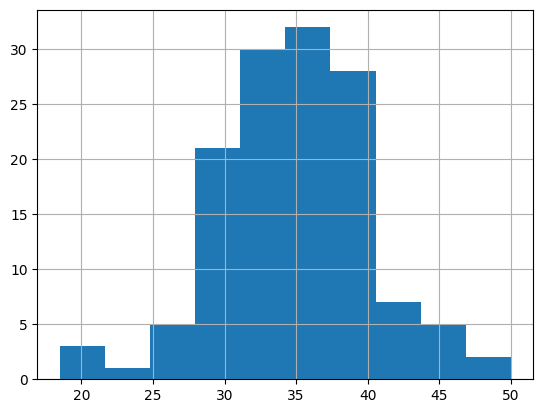

In [19]:
df_video_games["edad"].hist()

In [20]:
df_video_games["edad"].skew()

np.float64(-0.195780178573463)

In [21]:
media_edad_1 = df_video_games["edad"].mean()

df_video_games.fillna({"edad" : media_edad_1}, inplace=True)

df_video_games["edad"].skew()

np.float64(-0.20348164666133345)

In [22]:
pd.DataFrame(df_video_games.isnull().sum()/len(df_video_games), columns=["%"])["%"].round(2)

id              0.00
edad            0.00
genero          0.00
encuesta        0.00
satisfaccion    0.00
compra          0.09
articulos       0.39
Name: %, dtype: float64

#### Imputación a compra

<Axes: >

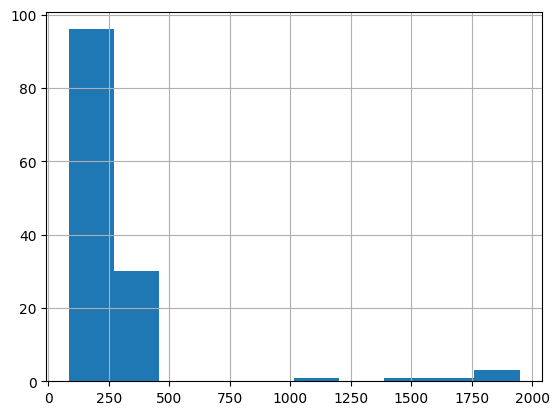

In [23]:
df_video_games["compra"].hist()

In [24]:
df_video_games["compra"].skew()

np.float64(4.4021804023394475)

In [25]:
median = df_video_games["compra"].median()

In [26]:
df_video_games.fillna({"compra" : median}, inplace = True)

df_video_games.isnull().sum()/len(df_video_games)

id              0.000000
edad            0.000000
genero          0.000000
encuesta        0.000000
satisfaccion    0.000000
compra          0.000000
articulos       0.393103
dtype: float64

In [27]:
df_video_games.drop("articulos", axis=1, inplace=True)

df_video_games.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145 entries, 0 to 187
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            145 non-null    int64  
 1   edad          145 non-null    float64
 2   genero        145 non-null    object 
 3   encuesta      145 non-null    int64  
 4   satisfaccion  145 non-null    float64
 5   compra        145 non-null    float64
dtypes: float64(3), int64(2), object(1)
memory usage: 7.9+ KB


In [28]:
df_house.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7559 entries, 0 to 7558
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             6856 non-null   object 
 1   Direccion        7559 non-null   object 
 2   CodigoPostal     7559 non-null   int64  
 3   Fecha            6520 non-null   object 
 4   Precio           6830 non-null   float64
 5   Habitaciones     7559 non-null   int64  
 6   Distacia         7559 non-null   float64
 7   Banos            7559 non-null   int64  
 8   Carros           7527 non-null   float64
 9   Terreno          7559 non-null   int64  
 10  Construccion     7129 non-null   float64
 11  AnoConstriccion  5074 non-null   float64
dtypes: float64(5), int64(4), object(3)
memory usage: 708.8+ KB


<Axes: >

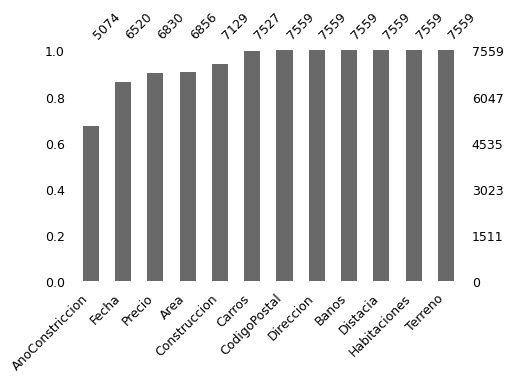

In [30]:
msg.bar(df_house, sort="ascending", figsize=(5,3), fontsize=9)

In [32]:
(df_house.isna().sum()/len(df_house)).round(2)

Area               0.09
Direccion          0.00
CodigoPostal       0.00
Fecha              0.14
Precio             0.10
Habitaciones       0.00
Distacia           0.00
Banos              0.00
Carros             0.00
Terreno            0.00
Construccion       0.06
AnoConstriccion    0.33
dtype: float64

In [36]:
result = df_house.isna()

print(a.sum())

print( result["Area"].sum(), result["Precio"].sum())

60
703 729


In [37]:
df_house.dropna(subset=['Area', 'Precio'], inplace=True)
df_house.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6187 entries, 0 to 6855
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             6187 non-null   object 
 1   Direccion        6187 non-null   object 
 2   CodigoPostal     6187 non-null   int64  
 3   Fecha            5325 non-null   object 
 4   Precio           6187 non-null   float64
 5   Habitaciones     6187 non-null   int64  
 6   Distacia         6187 non-null   float64
 7   Banos            6187 non-null   int64  
 8   Carros           6187 non-null   float64
 9   Terreno          6187 non-null   int64  
 10  Construccion     5823 non-null   float64
 11  AnoConstriccion  4109 non-null   float64
dtypes: float64(5), int64(4), object(3)
memory usage: 628.4+ KB


In [40]:
(df_house.isna().sum()/len(df_house)).round(2)

Area               0.00
Direccion          0.00
CodigoPostal       0.00
Fecha              0.14
Precio             0.00
Habitaciones       0.00
Distacia           0.00
Banos              0.00
Carros             0.00
Terreno            0.00
Construccion       0.06
AnoConstriccion    0.34
dtype: float64

In [41]:
df_house.drop(columns=["AnoConstriccion", "Fecha"], inplace=True)
df_house.head()

,Area,Direccion,CodigoPostal,Precio,Habitaciones,Distacia,Banos,Carros,Terreno,Construccion
0,Yarra,25 Bloomburg St,3067,1035000.0,2,2.5,1,0.0,156,79.0
1,Yarra,5 Charles St,3067,1465000.0,3,2.5,2,0.0,134,150.0
2,Yarra,55a Park St,3067,1600000.0,4,2.5,1,2.0,120,142.0
3,Yarra,124 Yarra St,3067,1876000.0,3,2.5,2,0.0,245,210.0
4,Yarra,98 Charles St,3067,1636000.0,2,2.5,1,2.0,256,107.0


In [42]:
(df_house.isna().sum()/len(df_house)).round(2)

Area            0.00
Direccion       0.00
CodigoPostal    0.00
Precio          0.00
Habitaciones    0.00
Distacia        0.00
Banos           0.00
Carros          0.00
Terreno         0.00
Construccion    0.06
dtype: float64

<Axes: >

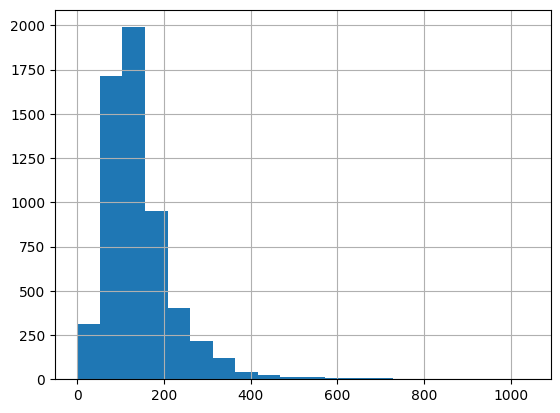

In [46]:
df_house['Construccion'].hist(bins=20)

In [45]:
df_house['Construccion'].skew()

np.float64(2.730084146613284)

In [47]:
df_house['Construccion'].describe()

count    5823.000000
mean      142.822597
std        85.759660
min         0.000000
25%        91.000000
50%       124.000000
75%       171.000000
max      1041.000000
Name: Construccion, dtype: float64

In [48]:
df_house.fillna({'Construccion' : df_house['Construccion'].median()}, inplace=True)
(df_house.isna().sum()/len(df_house)).round(2)

Area            0.0
Direccion       0.0
CodigoPostal    0.0
Precio          0.0
Habitaciones    0.0
Distacia        0.0
Banos           0.0
Carros          0.0
Terreno         0.0
Construccion    0.0
dtype: float64

### Duplicados

In [50]:
df_video_games_duplicates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            126 non-null    int64  
 1   edad          126 non-null    float64
 2   genero        126 non-null    object 
 3   encuesta      126 non-null    int64  
 4   satisfaccion  126 non-null    int64  
 5   compra        126 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 6.0+ KB


In [53]:
df_video_games_duplicates[df_video_games_duplicates.duplicated()]

,id,edad,genero,encuesta,satisfaccion,compra
105,1,25.5,Hombre,1,2,206.3
106,2,40.0,Hombre,1,5,297.9
107,3,30.0,Hombre,1,3,273.4
108,4,29.5,Mujer,1,5,327.6
109,8,34.5,Hombre,1,3,152.6
110,9,36.5,Mujer,1,5,276.5
111,12,35.0,Mujer,1,1,93.1
112,13,32.0,Hombre,1,5,136.3
113,17,28.5,Mujer,1,3,204.8
114,19,36.5,Mujer,1,5,337.7


In [54]:
df_video_games_duplicates.duplicated().sum()

np.int64(17)

In [61]:
df_video_games_duplicates[df_video_games_duplicates["id"] == 1]

,id,edad,genero,encuesta,satisfaccion,compra
0,1,25.5,Hombre,1,2,206.3
105,1,25.5,Hombre,1,2,206.3


In [62]:
df_video_games_duplicates.drop_duplicates(inplace=True)

In [63]:
df_video_games_duplicates.duplicated().sum()

np.int64(0)

In [ ]:
df_video_games_duplicates[df_video_games_duplicates["id"].duplicated()]

,id,edad,genero,encuesta,satisfaccion,compra
122,120,29.0,Hombre,1,2,768.5
123,123,40.5,Hombre,1,3,456.8
124,125,35.0,Hombre,1,4,190.5
125,126,35.5,Hombre,1,2,867.5


In [ ]:
df_video_games_duplicates["id"].isin([120,123,125,126])

0      False
1      False
2      False
3      False
4      False
       ...  
100    False
101    False
102    False
103    False
104    False
Name: id, Length: 105, dtype: bool

In [68]:
df_video_games_duplicates[df_video_games_duplicates["id"].isin([120,123,125,126])]

,id,edad,genero,encuesta,satisfaccion,compra
55,120,29.0,Hombre,1,2,162.7
56,123,40.5,Hombre,1,3,207.1
57,125,35.0,Hombre,1,4,156.9
58,126,35.5,Hombre,1,2,181.7
122,120,29.0,Hombre,1,2,768.5
123,123,40.5,Hombre,1,3,456.8
124,125,35.0,Hombre,1,4,190.5
125,126,35.5,Hombre,1,2,867.5


In [65]:
df_video_games_duplicates.drop_duplicates(subset=["id"], inplace=True)
df_video_games_duplicates[df_video_games_duplicates["id"].duplicated()]

,id,edad,genero,encuesta,satisfaccion,compra
